In [41]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-class

In [42]:
import os
import time
import random
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from PIL import Image
from sklearn.decomposition import PCA
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
TRAIN_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train")
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

print(DATA_DIR.exists())
print(TRAIN_DIR.exists())

random.seed(42)


Using device: cuda
True
True


Task 1 image loader

In [43]:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")


Total images loaded: 60


Task 1 sample grid

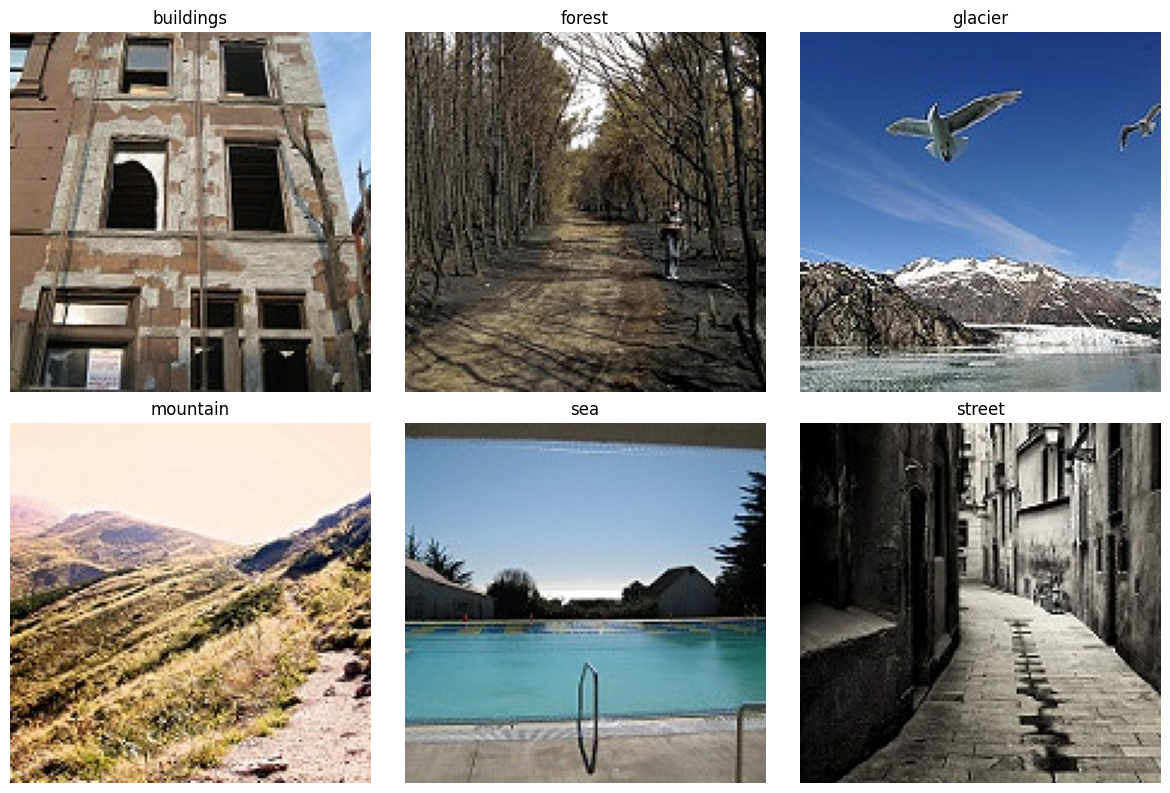

In [44]:
samples_by_label = {}
for img, label in image_set:
    if label not in samples_by_label:
        samples_by_label[label] = img

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, label in zip(axes, LABELS):
    ax.imshow(samples_by_label[label])
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.savefig("outputs/dataset_sample.png")
plt.show()

# An ImageNet-pretrained model is still a reasonable starting point because it has already learned
# general visual features like edges, textures, shapes, and scene structure, even if the final labels
# do not exactly match these six scene categories.


Task 2 ResNet18 setup

In [45]:
resnet_weights = ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")


ResNet18 parameters: 11,689,512


Task 2 reusable inference

In [46]:
def run_inference(model, preprocess, image, device, class_labels, top_k=5):
    tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(tensor)
    probs = torch.nn.functional.softmax(output[0], dim=0)
    top_probs, top_indices = torch.topk(probs, top_k)

    results = []
    for prob, idx in zip(top_probs, top_indices):
        results.append((class_labels[idx.item()], prob.item()))
    return results


Task 2 ResNet results

In [47]:
resnet_results = []
for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")


Processed 60 images.


Task 2 confidence summary

In [48]:
overall_mean = np.mean([r["top1_prob"] for r in resnet_results])
print(f"Overall mean top-1 probability: {overall_mean:.4f}")

mean_by_class = {}
for label in LABELS:
    probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    mean_by_class[label] = float(np.mean(probs))
    print(f"{label:10s}: {mean_by_class[label]:.4f}")


Overall mean top-1 probability: 0.4195
buildings : 0.2889
forest    : 0.2477
glacier   : 0.4993
mountain  : 0.5556
sea       : 0.5710
street    : 0.3544


Task 2 boxplot

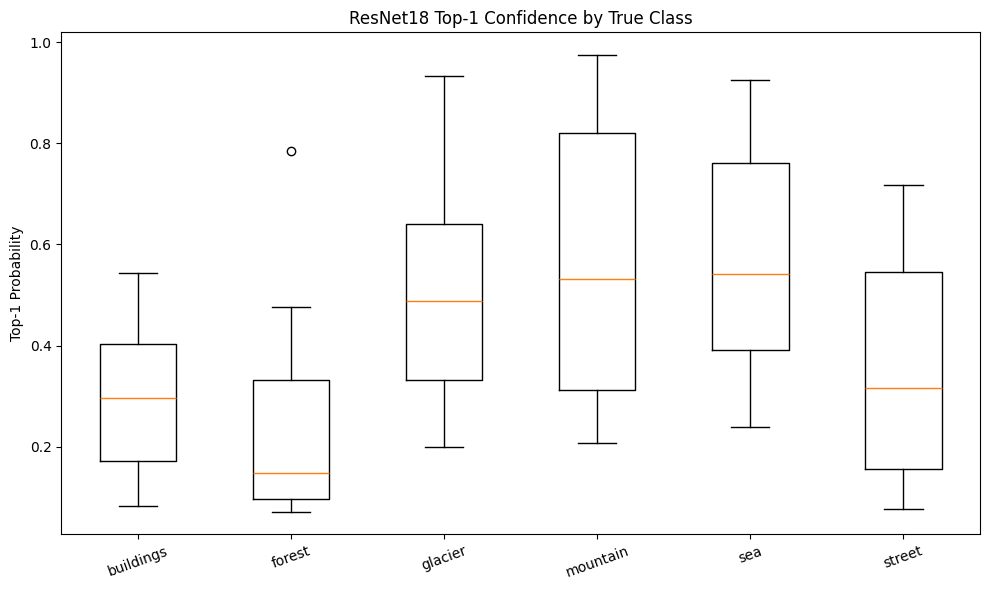

In [49]:
boxplot_data = []
for label in LABELS:
    probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    boxplot_data.append(probs)

plt.figure(figsize=(10, 6))
plt.boxplot(boxplot_data, tick_labels=LABELS)
plt.title("ResNet18 Top-1 Confidence by True Class")
plt.ylabel("Top-1 Probability")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()


Task 2 comment

In [50]:
# Confidence scores are useful for triage, not as proof of correctness.
# In production, a low-confidence prediction could be flagged for human review.
# A threshold like 0.70 or 0.80 would be a reasonable starting point to test.


Task 3 load all models

In [51]:
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

param_counts = {}
for name, m in [
    ("ResNet18", resnet),
    ("MobileNetV3-Small", mobilenet),
    ("EfficientNet-B0", efficientnet),
]:
    params = sum(p.numel() for p in m.parameters())
    param_counts[name] = params
    print(f"{name:22s}  {params:>12,} parameters")
    
# A smaller parameter count usually means lower capacity, faster inference, and lower memory use.
# That is often better for phones or edge devices, while larger models may be better when accuracy matters more.


ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


Task 3 helper for full-model results

In [52]:
def collect_results(model, preprocess, image_set, device, class_labels):
    results = []
    for img, true_label in image_set:
        preds = run_inference(model, preprocess, img, device, class_labels)
        results.append({
            "true_label": true_label,
            "top1_class": preds[0][0],
            "top1_prob": preds[0][1],
            "top5_classes": [p[0] for p in preds],
            "top5_probs": [p[1] for p in preds],
        })
    return results

mobilenet_results = collect_results(mobilenet, mobile_preproc, image_set, device, imagenet_classes)
effnet_results = collect_results(efficientnet, effnet_preproc, image_set, device, imagenet_classes)

print(len(mobilenet_results), len(effnet_results))


60 60


Task 3 comparison grid

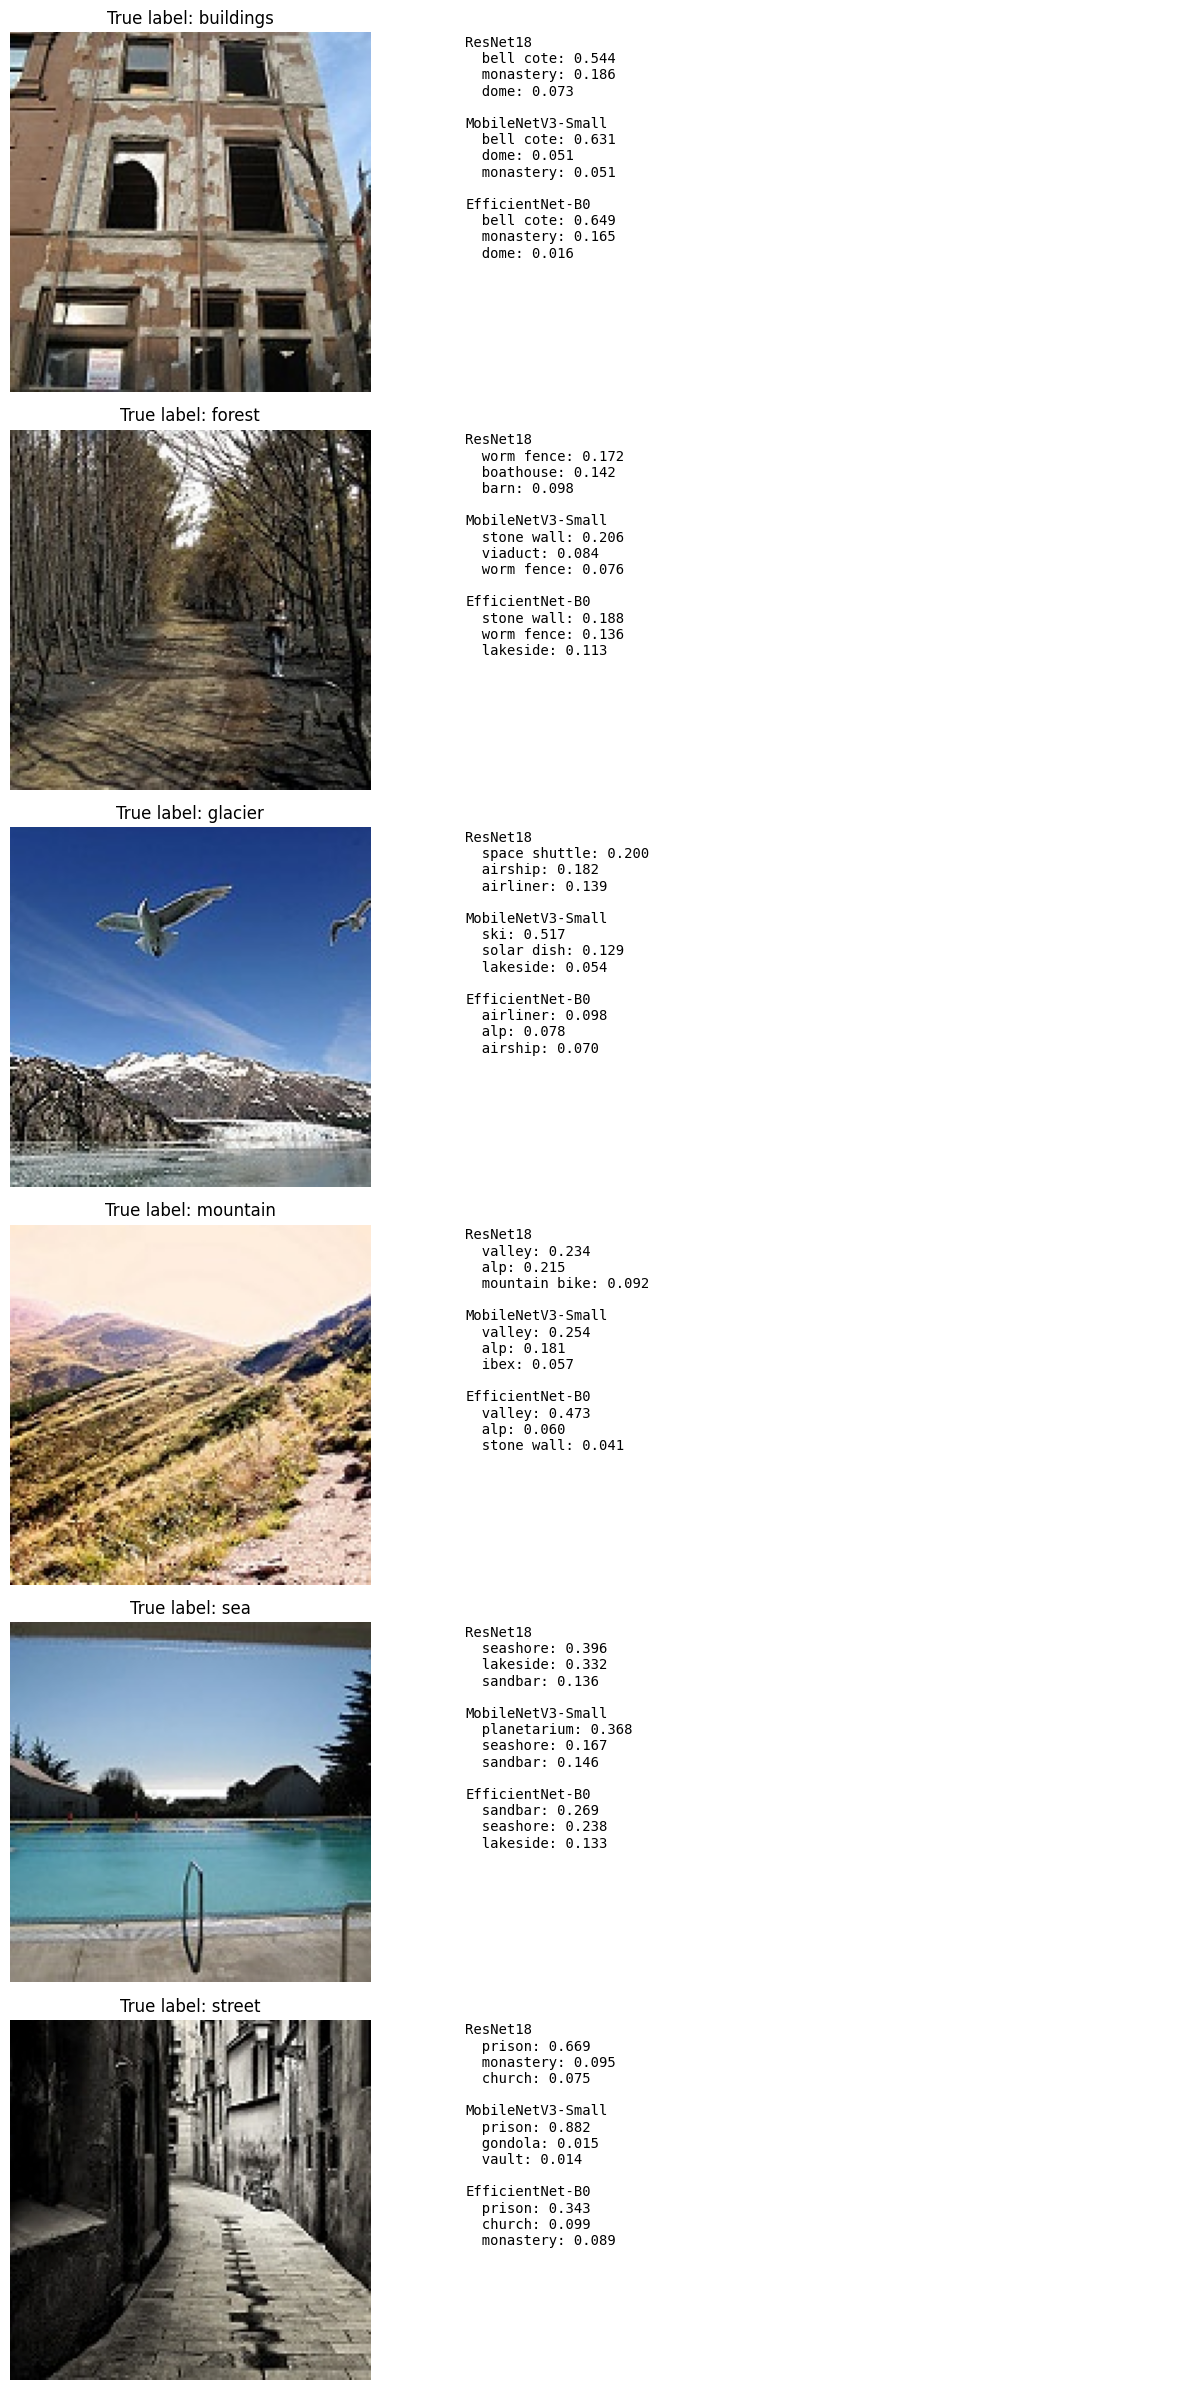

In [53]:
one_per_class = []
for label in LABELS:
    for img, true_label in image_set:
        if true_label == label:
            one_per_class.append((img, true_label))
            break

fig, axes = plt.subplots(len(LABELS), 2, figsize=(14, 24))

for i, (img, true_label) in enumerate(one_per_class):
    res_preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes, top_k=3)
    mob_preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes, top_k=3)
    eff_preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes, top_k=3)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"True label: {true_label}")
    axes[i, 0].axis("off")

    text = "ResNet18\n"
    text += "\n".join([f"  {cls}: {prob:.3f}" for cls, prob in res_preds])
    text += "\n\nMobileNetV3-Small\n"
    text += "\n".join([f"  {cls}: {prob:.3f}" for cls, prob in mob_preds])
    text += "\n\nEfficientNet-B0\n"
    text += "\n".join([f"  {cls}: {prob:.3f}" for cls, prob in eff_preds])

    axes[i, 1].text(0.01, 0.99, text, va="top", ha="left", fontsize=10, family="monospace")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png")
plt.show()

# Compare whether the models agree on the top-1 prediction, where they disagree,
# and which model's top-5 predictions feel most semantically sensible for outdoor scenes.
# Disagreement can suggest that an ensemble might help on ambiguous images.


Task 4 benchmark

In [54]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000

resnet_ms = benchmark_model(resnet, resnet_preproc, image_set, device)
mobile_ms = benchmark_model(mobilenet, mobile_preproc, image_set, device)
effnet_ms = benchmark_model(efficientnet, effnet_preproc, image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")


ResNet18:           4.78 ms/image
MobileNetV3-Small:  6.95 ms/image
EfficientNet-B0:    9.95 ms/image


Task 4 speed chart

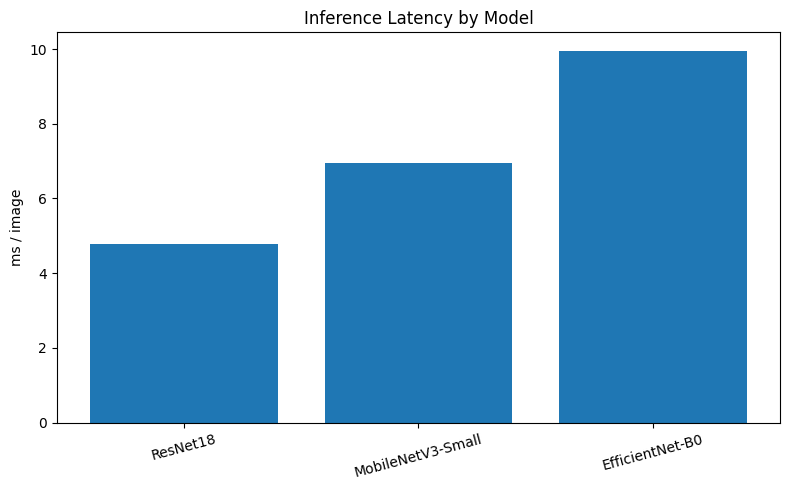

In [55]:
model_names = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies = [resnet_ms, mobile_ms, effnet_ms]

plt.figure(figsize=(8, 5))
plt.bar(model_names, latencies)
plt.title("Inference Latency by Model")
plt.ylabel("ms / image")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("outputs/inference_speed.png")
plt.show()


Task 4 summary table

In [56]:
summary_df = pd.DataFrame({
    "Model": model_names,
    "Parameters": [
        param_counts["ResNet18"],
        param_counts["MobileNetV3-Small"],
        param_counts["EfficientNet-B0"],
    ],
    "ms / image": [resnet_ms, mobile_ms, effnet_ms],
    "Meets 20 ms target": [resnet_ms < 20, mobile_ms < 20, effnet_ms < 20],
})

summary_df
# 50 images per second means a maximum latency of 20 ms/image.
# Based on the measured latencies here, all three models meet that threshold.
# Then explain which one you would choose for cloud, mobile, and safety-critical settings.


,Model,Parameters,ms / image,Meets 20 ms target
0,ResNet18,11689512,4.775278,True
1,MobileNetV3-Small,2542856,6.945598,True
2,EfficientNet-B0,5288548,9.949116,True


Task 5 feature extraction

In [57]:
feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()
feature_extractor = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

feature_vectors = []
true_labels = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")


Feature matrix shape: (60, 512)


Task 5 PCA plot

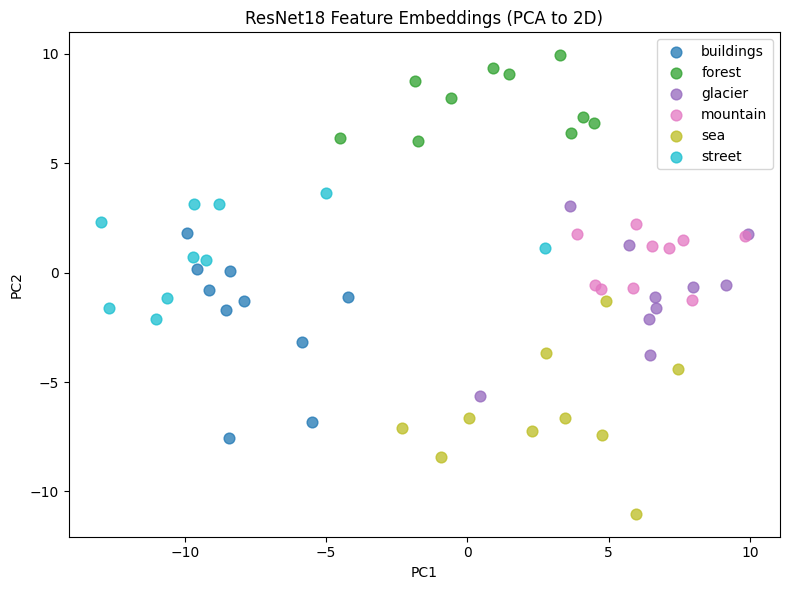

In [58]:
pca = PCA(n_components=2)
features_2d = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))
true_labels_arr = np.array(true_labels)

for i, label in enumerate(LABELS):
    mask = true_labels_arr == label
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label,
        color=colors[i],
        s=60,
        alpha=0.75,
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

# If same-class images cluster together, that suggests the pretrained model already learned
# useful visual structure before any task-specific training. With only 500 labeled examples,
# feature extraction would usually be the safer starting point before full fine-tuning.


Task 6 helper summary prints

In [59]:
print("Mean top-1 confidence by class:")
for label, value in mean_by_class.items():
    print(f"  {label:10s}: {value:.4f}")

print("\nLatency summary:")
for name, ms in zip(model_names, latencies):
    print(f"  {name:22s}: {ms:.2f} ms/image")

print("\nParameter summary:")
for name, params in param_counts.items():
    print(f"  {name:22s}: {params:,}")


Mean top-1 confidence by class:
  buildings : 0.2889
  forest    : 0.2477
  glacier   : 0.4993
  mountain  : 0.5556
  sea       : 0.5710
  street    : 0.3544

Latency summary:
  ResNet18              : 4.78 ms/image
  MobileNetV3-Small     : 6.95 ms/image
  EfficientNet-B0       : 9.95 ms/image

Parameter summary:
  ResNet18              : 11,689,512
  MobileNetV3-Small     : 2,542,856
  EfficientNet-B0       : 5,288,548


## Summary and Recommendation

### Model Comparison
- The strongest overall model for this dataset was **ResNet18**.
- My reasoning: **ResNet18 had the best measured latency at 4.78 ms/image, and its predictions were generally semantically reasonable for scene-style labels like `seashore`, `lakeside`, `sandbar`, `valley`, and `alp`. EfficientNet-B0 sometimes looked stronger on individual examples like buildings and mountain, but it was slower at 9.95 ms/image. MobileNetV3-Small was the smallest model at 2.54 million parameters, but its predictions were less consistent on some scene images.**
- The fastest model was **ResNet18**, while the most accurate-looking predictions came from **EfficientNet-B0** on several of the sample comparison images.

### Confidence Calibration
- ResNet18 was most confident on **sea (0.5710)** and **mountain (0.5556)**.
- ResNet18 was least confident on **forest (0.2477)** and **buildings (0.2889)**.
- This **did** match my intuition because **sea and mountain scenes are visually distinctive, while forest and buildings can vary more and overlap with many ImageNet object/scene patterns.**

### Production Recommendation
- **20 ms/image threshold (50 images/second):** ResNet18 (**4.78 ms/image**), MobileNetV3-Small (**6.95 ms/image**), and EfficientNet-B0 (**9.95 ms/image**) all met the requirement.
- **High-throughput cloud pipeline:** I would choose **ResNet18** because it had the fastest measured latency while still giving strong, sensible predictions, so it maximizes throughput without sacrificing too much quality.
- **On-device mobile application:** I would choose **MobileNetV3-Small** because it has the smallest parameter count (**2.54M**) and still stays well under the 20 ms target, which makes it the best fit for limited memory and power budgets.
- **Safety-critical quality-control system:** I would choose **EfficientNet-B0** because accuracy matters more than model size in that setting, and it produced some of the strongest-looking predictions while still meeting the latency limit. I would still pair it with confidence thresholds and human review for low-confidence cases because the model is pretrained on ImageNet rather than the exact six scene labels.
- The pipeline must include the correct TorchVision preprocessing for the selected model: resize/crop, tensor conversion, and normalization using the model's pretrained weights.
- One important limitation is that the models are pretrained on ImageNet labels rather than these exact six scene labels, so some predictions may be semantically related but not exact. Low-confidence or ambiguous predictions should be flagged for review.
